<a href="https://colab.research.google.com/github/Doufoungognon/portfolio/blob/main/%D0%A0%D0%B5%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/harvardnlp/annotated-transformer/blob/master/the_annotated_transformer.py

In [ ]:
!pip install -q torchtext altair GPUtil

In [ ]:
import os
from os.path import exists
import torch
import torch.nn as nn
from torch.nn.functional import log_softmax, pad
import math
import copy
import time
from torch.optim.lr_scheduler import LambdaLR
import pandas as pd
import altair as alt
# from torchtext.data.functional import to_map_style_dataset
from torch.utils.data import DataLoader
# from torchtext.vocab import build_vocab_from_iterator
# import torchtext.datasets as datasets
# import spacy
import GPUtil
import warnings
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set to False to skip notebook execution (e.g. for debugging)
warnings.filterwarnings("ignore")
RUN_EXAMPLES = True

In [ ]:
def show_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)

def execute_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        fn(*args)

class DummyOptimizer(torch.optim.Optimizer):
    def __init__(self):
        self.param_groups = [{"lr": 0}]
        None

    def step(self):
        None

    def zero_grad(self, set_to_none=False):
        None

class DummyScheduler:
    def step(self):
        None


def is_interactive_notebook():
    return __name__ == "__main__"


## **Общая архитектура Encoder-Decoder**

In [ ]:
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder      # Энкодер
        self.decoder = decoder      # Декодер
        self.src_embed = src_embed  # Эмбеддинги для исходного текста
        self.tgt_embed = tgt_embed  # Эмбеддинги для целевого текста
        self.generator = generator  # Линейный слой для генерации слов

    def forward(self, src, tgt, src_mask, tgt_mask):
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

Generator - это просто линейный слой + softmax, который преобразует вектор размерности `d_model` в вероятности слов словаря

In [ ]:
class Generator(nn.Module):
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)  # Проекция на размер словаря

    def forward(self, x):
        return log_softmax(self.proj(x), dim=-1)  # Логарифм вероятностей



### Encoder

Энкодер состоит из $N$ (обычно 6) одинаковых слоев.

Каждый слой содержит:

- Self-Attention
- Feed-Forward Network



In [ ]:
def clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [ ]:
class Encoder(nn.Module):
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)  # N одинаковых слоев
        self.norm = LayerNorm(layer.size)  # Нормализация в конце

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

#### Layer Normalization

$x$ → LayerNorm → Self-Attention → Residual Connection →
  LayerNorm → Feed-Forward → Residual Connection → выход



In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2


#### Residual Connection

In [ ]:
class SublayerConnection(nn.Module):
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))



Таким образом, выход каждого подблока это $\mathrm{LayerNorm}(x +
\mathrm{Sublayer}(x))$. Также перед прокидыванием связи к выходу $\mathrm{Sublayer}(x)$ применяется дропаут.

Чтобы работало прокидывание связи, все подблоки в модели, а также эмбеддинг-слои выдают векторы фиксированной размерности $d_{\text{model}}=512$.

Заметим, LayerNorm идет перед основным преобразованием подблока, а не после него, как в ориганльной статье 2017г.

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

### Декодер

Декодер похож на энкодер, но с тремя подслоями:

- Masked Self-Attention (внимание с маской)

- Encoder-Decoder Attention (внимание к выходу энкодера)

- Feed-Forward Network

 Также как и в энкодере, вокруг каждого подблока есть прокидывание связей и нормализация.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

**Маскирование** нужно для того, чтобы трансформер не заглядывал в "будущее". Также, важным является то, что вход трансформера сдвинут на 1 позицию вправо, чтобы гарантировать, что предсказание на позиции $i$ зависит только от элементов <= $i$.


In [ ]:
def subsequent_mask(size):
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(
        torch.uint8
    )
    return subsequent_mask == 0

### Внимание

Иллюстрация механизма MHA в трансформере:
![Механизм attention](https://jalammar.github.io/images/t/transformer_multi-headed_self-attention-recap.png)

Многомерное внимание (**MultiHead Attention**, **MHA**) позволяет модели выучивать различные аспекты текста. Например, грамматику, синтаксические связи, связи между разными частями текста.

$$
\mathrm{MultiHead}(Q, K, V) =
    \mathrm{Concat}(\mathrm{head_1}, ..., \mathrm{head_h})W^O \\
    \text{where}~\mathrm{head_i} = \mathrm{Attention}(QW^Q_i, KW^K_i, VW^V_i)
$$

Проекционные матрицы $W^Q_i \in
\mathbb{R}^{d_{\text{model}} \times d_k}$, $W^K_i \in
\mathbb{R}^{d_{\text{model}} \times d_k}$, $W^V_i \in
\mathbb{R}^{d_{\text{model}} \times d_v}$ and $W^O \in
\mathbb{R}^{hd_v \times d_{\text{model}}}$, являются обучаемыми параметрами.

In [ ]:
def attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)  # Маскирование

    p_attn = scores.softmax(dim=-1)  # Веса внимания
    if dropout is not None:
        p_attn = dropout(p_attn)

    return torch.matmul(p_attn, value), p_attn

```python
Input: (batch, seq_len, d_model)
    ↓ [Линейные проекции Q, K, V]
(batch, seq_len, d_model) → разделение на h голов → (batch, h, seq_len, d_k)
    ↓ [Attention для каждой головы]
(batch, h, seq_len, d_k)
    ↓ [Конкатенация]
(batch, seq_len, d_model)
    ↓ [Выходной линейный слой]
Output: (batch, seq_len, d_model)
```

In [ ]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        # Предполагаем, что d_v равно d_k
        self.d_k = d_model // h  # Размерность каждого "головы"
        self.h = h  # Количество голов (обычно 8)
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        if mask is not None:
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1.Для каждого элемента по батчам делаем линейные проекции d_model => h x d_k
        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ]
        # 2.Применяем внимание
        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        )
        # 3. Конкатинация голов в d_model
        x = (
            x.transpose(1, 2)
            .contiguous()
            .view(nbatches, -1, self.h * self.d_k)
        )
        del query
        del key
        del value
        # применяем последний линейный слой
        return self.linears[-1](x)


### Position-wise Feed-Forward Networks

В дополнение к подблокам внимания, каждый из блоков в энкодере и декодере содержит полносвязную сеть, которая применяется к каждой позиции отдельно.
Она состоит из двух линейных преобразований с активацией ReLU между ними.

$$\mathrm{FFN}(x)=\max(0, xW_1 + b_1) W_2 + b_2$$

Хотя линейные преобразования одинаковы для разных позиций, они используют разные параметры от блока к блоку. Размерность ввода и вывода равна $d_{\text{model}}=512$, а внутренний слой имеет размерность $d_{ff}=2048$.

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(self.w_1(x).relu()))


### Position encoding

Позиционные эмбеддинги имеют ту же размерность $d_{\text{model}}$, что и эмбеддинги токенов, так чтобы их можно было суммировать. Есть много вариантов позиционных кодировок, обучаемых и фиксированных [(cite)](https://arxiv.org/pdf/1705.03122.pdf).

В классическом трансформере используются функции синуса и косинуса разных частот:

$$PE_{(pos,2i)} = \sin(pos / 10000^{2i/d_{\text{model}}})$$

$$PE_{(pos,2i+1)} = \cos(pos / 10000^{2i/d_{\text{model}}})$$

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)


torch.Size([1, 1000, 512])


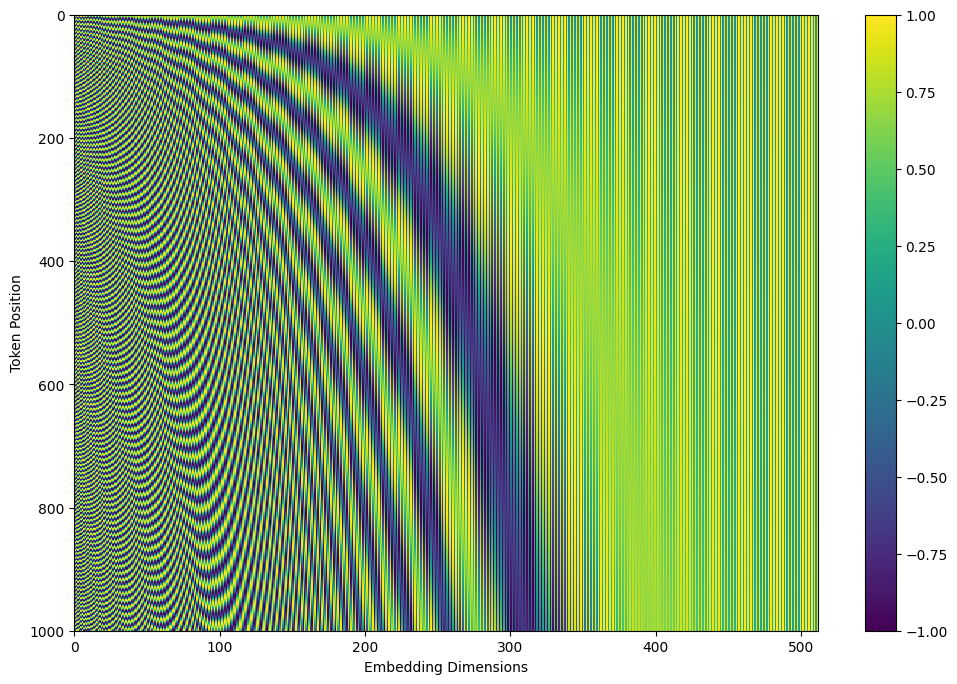

In [ ]:
tokens = 1000
dimensions = 512

pe = PositionalEncoding(dimensions, 0)
pos_encoding = pe.forward(torch.zeros(1, tokens, dimensions))

pos_encodings = pos_encoding.reshape([1, tokens, dimensions]).numpy()
print(pos_encoding.shape)

plt.figure(figsize=(12,8))
plt.pcolormesh(pos_encoding[0], cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, dimensions))
plt.ylim((tokens,0))
plt.ylabel('Token Position')
plt.colorbar()
plt.show()

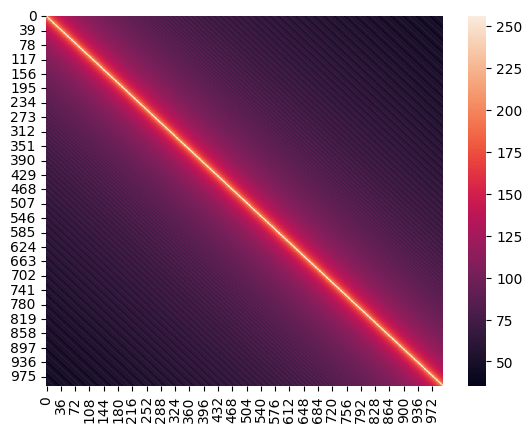

In [ ]:
dot_matrix = pos_encodings[0] @ pos_encodings[0].T
sns.heatmap(dot_matrix)
plt.show()

## Полная архитектура

```python

Input → Embeddings + PositionalEncoding → ENCODER:
    [EncoderLayer × N]:
        Self-Attention → Add & Norm → FFN → Add & Norm
    ↓
Encoder Output

Input → Embeddings + PositionalEncoding → DECODER:
    [DecoderLayer × N]:
        Masked Self-Attention → Add & Norm
        ↓
        Cross-Attention (с Encoder output) → Add & Norm
        ↓
        FFN → Add & Norm
    ↓
Decoder Output → Generator → Output Probabilities

```

In [ ]:
def make_model(
    src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1
):
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model


## Обучение Transformer

In [ ]:
class Batch:
    """Object for holding a batch of data with mask during training."""

    def __init__(self, src, tgt=None, pad=2):  # 2 = <blank>
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)  # маска паддинга
        if tgt is not None:
            self.tgt = tgt[:, :-1]    # Вход декодера
            # teacher forcing, на вход декодера подаются правильные слова (со сдвигом).
            self.tgt_y = tgt[:, 1:]   # Целевые слова (сдвиг на 1)

            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(
            tgt_mask.data
        )
        return tgt_mask

### Цикл обучения

In [ ]:
class TrainState:
    """Track number of steps, examples, and tokens processed"""

    step: int = 0  # Steps in the current epoch
    accum_step: int = 0  # Number of gradient accumulation steps
    samples: int = 0  # total # of examples used
    tokens: int = 0  # total # of tokens processed

In [ ]:
def run_epoch(
    data_iter,     # Итератор данных (батчи)
    model,          # Модель Transformer
    loss_compute,   # Функция вычисления потерь
    optimizer,      # Оптимизатор
    scheduler,      # Планировщик learning rate
    mode="train",   # Режим: "train", "val", "test", "train+log"
    accum_iter=1,   # Сколько шагов накапливать градиенты
    train_state=TrainState(),  # Состояние обучения
    ):
    """Train a single epoch"""
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    n_accum = 0
    for i, batch in enumerate(data_iter):
        # прямой проход
        out = model.forward(
        batch.src,      # Исходные последовательности
        batch.tgt,      # Целевые последовательности (для teacher forcing)
        batch.src_mask, # Маска для encoder (pad masking)
        batch.tgt_mask  # Маска для decoder (pad + future masking)
        )
        loss, loss_node = loss_compute(out, batch.tgt_y, batch.ntokens)
        # обратный проход backward
        if mode == "train" or mode == "train+log":
            loss_node.backward()
            train_state.step += 1
            train_state.samples += batch.src.shape[0]  # Количество примеров
            train_state.tokens += batch.ntokens        # Количество токенов
            if i % accum_iter == 0:
              optimizer.step()                   # Обновление весов
              optimizer.zero_grad(set_to_none=True)  # Обнуление градиентов
              n_accum += 1
              train_state.accum_step += 1
            scheduler.step()                  # Обновление learning rate

        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens
        # логирование
        if i % 40 == 1 and (mode == "train" or mode == "train+log"):
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                (
                    " | Loss: %6.2f "
                    + "| Tokens / Sec: %7.1f | Learning Rate: %6.1e"
                )
                % (loss / batch.ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0
        del loss
        del loss_node
    return total_loss / total_tokens, train_state

### Оптимайзер

В статье использовался Adam [(cite)](https://arxiv.org/abs/1412.6980) с параметрами $\beta_1=0.9$, $\beta_2=0.98$ и $\epsilon=10^{-9}$.

Learning rate варьировался по следующей формуле:

$$
lrate = d_{\text{model}}^{-0.5} \cdot
  \min({step\_num}^{-0.5},
    {step\_num} \cdot {warmup\_steps}^{-1.5})
$$

Это соответствует линейному увеличению learning rate для первых $warmup\_steps$ шагов. Далее learning rate уменьшается пропорционально обратному квадратному корню из номера шага. Использовался $warmup\_steps=4000$.

In [ ]:
def rate(step, model_size, factor, warmup):
    """
    we have to default the step to 1 for LambdaLR function
    to avoid zero raising to negative power.
    """
    if step == 0:
        step = 1
    return factor * (
        model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))
    )

In [ ]:
def example_learning_schedule():
    opts = [
        [512, 1, 4000],  # example 1
        [512, 1, 8000],  # example 2
        [256, 1, 4000],  # example 3
    ]

    dummy_model = torch.nn.Linear(1, 1)
    learning_rates = []

    # we have 3 examples in opts list.
    for idx, example in enumerate(opts):
        # run 20000 epoch for each example
        optimizer = torch.optim.Adam(
            dummy_model.parameters(), lr=1, betas=(0.9, 0.98), eps=1e-9
        )
        lr_scheduler = LambdaLR(
            optimizer=optimizer, lr_lambda=lambda step: rate(step, *example)
        )
        tmp = []
        # take 20K dummy training steps, save the learning rate at each step
        for step in range(20000):
            tmp.append(optimizer.param_groups[0]["lr"])
            optimizer.step()
            lr_scheduler.step()
        learning_rates.append(tmp)

    learning_rates = torch.tensor(learning_rates)

    # Enable altair to handle more than 5000 rows
    alt.data_transformers.disable_max_rows()

    opts_data = pd.concat(
        [
            pd.DataFrame(
                {
                    "Learning Rate": learning_rates[warmup_idx, :],
                    "model_size:warmup": ["512:4000", "512:8000", "256:4000"][
                        warmup_idx
                    ],
                    "step": range(20000),
                }
            )
            for warmup_idx in [0, 1, 2]
        ]
    )

    return (
        alt.Chart(opts_data)
        .mark_line()
        .properties(width=600)
        .encode(x="step", y="Learning Rate", color="model_size:warmup:N")
        .interactive()
    )


example_learning_schedule()

ValueError: "warmup" is not one of the valid encoding data types: O, N, Q, T, G.
For more details, see https://altair-viz.github.io/user_guide/encodings/index.html#encoding-data-types. If you are trying to use a column name that contains a colon, prefix it with a backslash; for example "column\:name" instead of "column:name".

alt.Chart(...)

### Регуляризация

Label Smoothing

Во время обучения используем **label smoothing** со значением $\epsilon_{ls}=0.1$ [(cite)](https://arxiv.org/abs/1512.00567). Это уменьшает перплексию, поскольку модель учится быть более неуверенной, но при этом повышается точность и значение метрики BLEU на реальных данных.

In [ ]:
import torch
import torch.nn as nn

class LabelSmoothing(nn.Module):
    """Implement label smoothing."""
    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))

        #
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)

        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.clone().detach())

## Пример на синтетических данных

Модель должна научиться копировать входную последовательность

In [ ]:
def data_gen(V, batch_size, nbatches):
    "Генерация случайной последовательностей src-tgt"
    for i in range(nbatches):
        data = torch.randint(1, V, size=(batch_size, 10))
        data[:, 0] = 1
        src = data.requires_grad_(False).clone().detach()
        tgt = data.requires_grad_(False).clone().detach()
        # tgt = torch.flip(data, dims=[1]).requires_grad_(False).clone().detach()
        yield Batch(src, tgt, 0)

In [ ]:
class SimpleLossCompute:
    "линейный слой + softmax, CrossEntropy, нормализация"

    def __init__(self, generator, criterion):
        self.generator = generator
        self.criterion = criterion

    def __call__(self, x, y, norm):
        x = self.generator(x)
        sloss = (
            self.criterion(
                x.contiguous().view(-1, x.size(-1)), y.contiguous().view(-1)
            )
            / norm
        )
        return sloss.data * norm, sloss

In [ ]:
# Обучение

def train_simple_model(n_epochs, **model_params):
    V = 11
    criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)
    # model = make_model(V, V, N=1, h=1)
    model = make_model(V, V, **model_params)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=0.5, betas=(0.9, 0.98), eps=1e-9
    )
    lr_scheduler = LambdaLR(
        optimizer=optimizer,
        lr_lambda=lambda step: rate(
            step, model_size=model.src_embed[0].d_model, factor=1.0, warmup=400
        ),
    )

    batch_size = 80
    ts = TrainState()
    for epoch in range(n_epochs):
        print(f'Epoch {epoch}', end='')
        model.train()
        run_epoch(
            data_gen(V, batch_size, 20),
            model,
            SimpleLossCompute(model.generator, criterion),
            optimizer,
            lr_scheduler,
            mode="train",
        )
        model.eval()
        run_epoch(
            data_gen(V, batch_size, 5),
            model,
            SimpleLossCompute(model.generator, criterion),
            DummyOptimizer(),
            DummyScheduler(),
            mode="eval",
        )

    model.eval()
    return model

In [ ]:
model = train_simple_model(10, N=2, h=1)

Epoch 0 | Loss:   3.30 | Tokens / Sec:   357.4 | Learning Rate: 5.5e-06
Epoch 1 | Loss:   2.17 | Tokens / Sec:   456.0 | Learning Rate: 6.1e-05
Epoch 2 | Loss:   1.79 | Tokens / Sec:   449.9 | Learning Rate: 1.2e-04
Epoch 3 | Loss:   1.25 | Tokens / Sec:   440.6 | Learning Rate: 1.7e-04
Epoch 4 | Loss:   0.83 | Tokens / Sec:   383.3 | Learning Rate: 2.3e-04
Epoch 5 | Loss:   0.51 | Tokens / Sec:   425.1 | Learning Rate: 2.8e-04
Epoch 6 | Loss:   0.41 | Tokens / Sec:   442.9 | Learning Rate: 3.4e-04
Epoch 7 | Loss:   0.26 | Tokens / Sec:   411.1 | Learning Rate: 3.9e-04
Epoch 8 | Loss:   0.32 | Tokens / Sec:   445.2 | Learning Rate: 4.5e-04
Epoch 9 | Loss:   0.19 | Tokens / Sec:   443.2 | Learning Rate: 5.0e-04


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def get_encoder_self(model, layer):
    return model.encoder.layers[layer].self_attn.attn


def get_decoder_self(model, layer):
    return model.decoder.layers[layer].self_attn.attn


def get_decoder_src(model, layer):
    return model.decoder.layers[layer].src_attn.attn

Создаём инференс:

In [ ]:
src = torch.LongTensor([[1, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5]])
print('sourse:\t', src)
# print('target:\t', torch.flip(src, dims=[1]))
max_len = src.shape[1]
src_mask = torch.ones(1, 1, max_len)
print('pred:\t', greedy_decode(model, src, src_mask, max_len=max_len, start_symbol=1))

sourse:	 tensor([[1, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5]])
pred:	 tensor([[1, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5]])


In [ ]:
get_encoder_self(model, 0).size()

torch.Size([1, 1, 12, 12])

In [ ]:
get_decoder_src(model, 0).size()

torch.Size([1, 1, 11, 12])

In [ ]:
get_decoder_self(model, 0).size()

torch.Size([1, 1, 11, 11])

```python

Input: "The animal didn't cross the street because it was too tired"

Визуализация внимания от слова "it":
[The, animal, didn't, cross, the, street, because, it, was, too, tired]
                                ↓ внимание ↓
[ 0.0,  0.9,    0.0,   0.0,  0.0,   0.0,    0.0,  0.1, 0.0, 0.0,   0.0]
       ↑ слово "animal" получает 90% внимания

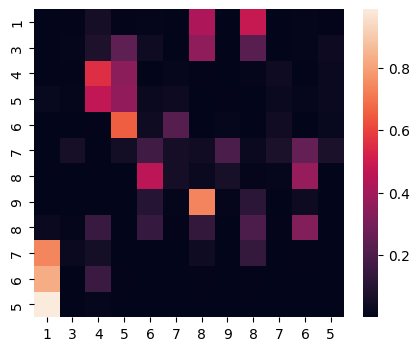

In [ ]:
# @title Encoder Self-Attention
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(get_encoder_self(model, 1)[0][0].data)
ax.set_xticklabels(src[0].tolist())
ax.set_yticklabels(src[0].tolist())
plt.show()

```python

Source (EN): "I love machine learning"
Target (FR): "J'aime l'apprentissage automatique"

При генерации слова "automatique":
Source: [I, love, machine, learning]
         ↓ внимание ↓
        [0.0, 0.1, 0.4, 0.5]
               ↑      ↑    ↑
              love  machine learning

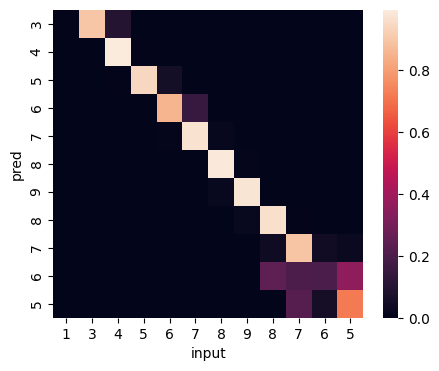

In [ ]:
# @title Decoder Cross-Attention
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(get_decoder_src(model, 0)[0][0].data)
ax.set_xticklabels(src[0].tolist())
ax.set_xlabel('input')
ax.set_yticklabels(src[0, 1:].tolist())
ax.set_ylabel('pred')
plt.show()


```python
Частично сгенерировано: "The cat sat on the"
Генерируем следующее слово: "mat"

Decoder self-attention для позиции "mat":
[The, cat, sat, on, the]  ← уже сгенерированные
 ↓ внимание ↓
[0.1, 0.3, 0.1, 0.4, 0.1]
        ↑    ↑     ↑
       cat   sat   on  (самые важные)

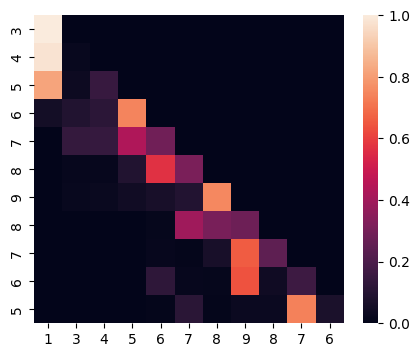

In [ ]:
# @title Decoder Self-Attention
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(get_decoder_self(model, 0)[0][0].data)
ax.set_xticklabels(src[0, 0:-1].tolist())
ax.set_yticklabels(src[0, 1:].tolist())
plt.show()
